# Lab 5 - Linear Regression


- Your name: Trịnh Hửu Thọ

- Your student code: 22110238

## I. Hướng dẫn

### 1.1. Khởi tạo Spark

In [2]:
import findspark
findspark.init()

import pyspark
findspark.find()

from pyspark.sql import SparkSession
from pyspark.sql.functions import count

spark = (SparkSession
         .builder
         .appName("Linear Regression")
         .getOrCreate())

### 1.2. Đọc và load tập dữ liệu Boston housing

In [3]:
bostonDF = (spark.read
            .option("HEADER", True)
            .option("inferSchema", True)
            .csv("./data/BostonHousing.csv")
           )

bostonDF.show(5)

+-------+----+-----+----+-----+-----+----+------+---+---+-------+------+-----+----+
|   crim|  zn|indus|chas|  nox|   rm| age|   dis|rad|tax|ptratio|     b|lstat|medv|
+-------+----+-----+----+-----+-----+----+------+---+---+-------+------+-----+----+
|0.00632|18.0| 2.31|   0|0.538|6.575|65.2|  4.09|  1|296|   15.3| 396.9| 4.98|24.0|
|0.02731| 0.0| 7.07|   0|0.469|6.421|78.9|4.9671|  2|242|   17.8| 396.9| 9.14|21.6|
|0.02729| 0.0| 7.07|   0|0.469|7.185|61.1|4.9671|  2|242|   17.8|392.83| 4.03|34.7|
|0.03237| 0.0| 2.18|   0|0.458|6.998|45.8|6.0622|  3|222|   18.7|394.63| 2.94|33.4|
|0.06905| 0.0| 2.18|   0|0.458|7.147|54.2|6.0622|  3|222|   18.7| 396.9| 5.33|36.2|
+-------+----+-----+----+-----+-----+----+------+---+---+-------+------+-----+----+
only showing top 5 rows


### 1.3. Giới thiệu tập dữ liệu Boston housing

`crim`: per capita crime rate by town.

`zn`: proportion of residential land zoned for lots over 25,000 sq.ft.

`indus`: proportion of non-retail business acres per town.

`chas`: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).

`nox`: nitrogen oxides concentration (parts per 10 million).

`rm`: average number of rooms per dwelling.

`age`: proportion of owner-occupied units built prior to 1940.

`dis`: weighted mean of distances to five Boston employment centres.

`rad`: index of accessibility to radial highways.

`tax`: full-value property-tax rate per 10,000 dollars.

`ptratio`: pupil-teacher ratio by town.

`b` (`black`): $1000(Bk - 0.63)^2$ where $Bk$ is the proportion of blacks by town.

`lstat`: lower status of the population (percent).

`medv`: median value of owner-occupied homes in 1000 dollars.

### 1.4. Tạo các biến input (features) và output (label)

Spark khác với nhiều machine learning framework khác ở chỗ ta cần huấn luyện mô hình của mình trên một cột duy nhất có chứa một vectơ gồm tất cả các feature (attribute) mà ta quan tâm. Ta sẽ chuẩn bị dữ liệu bằng cách tạo một cột có tên `features` gồm các thuộc tính `rm` (average number of rooms), `crim` (crime rate),  và `lstat` (lower status of the population).

Thêm cột `features` vừa tạo vào data frame sử dụng `VectorAssembler`:

In [4]:
from pyspark.ml.feature import VectorAssembler

featureCols = ["rm", "crim", "lstat"]
assembler = VectorAssembler(inputCols = featureCols, outputCol = "features")
bostonFeaturizedDF = assembler.transform(bostonDF)

bostonFeaturizedDF.show(5)

+-------+----+-----+----+-----+-----+----+------+---+---+-------+------+-----+----+--------------------+
|   crim|  zn|indus|chas|  nox|   rm| age|   dis|rad|tax|ptratio|     b|lstat|medv|            features|
+-------+----+-----+----+-----+-----+----+------+---+---+-------+------+-----+----+--------------------+
|0.00632|18.0| 2.31|   0|0.538|6.575|65.2|  4.09|  1|296|   15.3| 396.9| 4.98|24.0|[6.575,0.00632,4.98]|
|0.02731| 0.0| 7.07|   0|0.469|6.421|78.9|4.9671|  2|242|   17.8| 396.9| 9.14|21.6|[6.421,0.02731,9.14]|
|0.02729| 0.0| 7.07|   0|0.469|7.185|61.1|4.9671|  2|242|   17.8|392.83| 4.03|34.7|[7.185,0.02729,4.03]|
|0.03237| 0.0| 2.18|   0|0.458|6.998|45.8|6.0622|  3|222|   18.7|394.63| 2.94|33.4|[6.998,0.03237,2.94]|
|0.06905| 0.0| 2.18|   0|0.458|7.147|54.2|6.0622|  3|222|   18.7| 396.9| 5.33|36.2|[7.147,0.06905,5.33]|
+-------+----+-----+----+-----+-----+----+------+---+---+-------+------+-----+----+--------------------+
only showing top 5 rows


### 1.5. Tạo mô hình Linear Regression

Import thư viện linear regression và thiết lập output là thuộc tính `medv`, input là `features`. Tham khảo thêm về các tham số của thư viện LinearRegression ở [đây](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.LinearRegression.html#pyspark.ml.regression.LinearRegression).

In [5]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(labelCol = "medv", featuresCol = "features")

### 1.6. Fit mô hình với data

In [6]:
lrModel = lr.fit(bostonFeaturizedDF)

### 1.7. Xem các tham số của mô hình sau khi đã fit với data

In [7]:
print("Coefficients: {0:.1f}, {1:.1f}, {2:.1f}".format(*lrModel.coefficients))
print("Intercept: {0:.1f}".format(lrModel.intercept))

Coefficients: 5.2, -0.1, -0.6
Intercept: -2.6


**Ý nghĩa**: $predicted\_medv = (5.2 * rm) - (0.1 * crim) - (0.6 * lstat) - 2.6$

hay $predicted\_medv = (5.2 * number\_of\_rooms) - (0.1 * crime\_rate) - (0.6 * lower\_class) - 2.6$

Hai độ đo đánh giá thường được dùng là Root Mean Squared Error (RMSE) và R-Squared score ($R^2$).

$$RMSE(y, \hat{y}) = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y_i})^2}$$

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y_i})^2}{\sum_{i=1}^{n} (y_i - \overline{y})^2}$$

Trong đó:

- $\hat{y_i}$ là giá trị mà mô hình dự đoán cho $x_i$
    
- $y_i$ là output thật sự cho $x_i$
    
- $n$ là số lượng phần tử trong tập dữ liệu
    
- $\overline{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$

In [8]:
print("R-Squared score: {}".format(lrModel.summary.r2))

R-Squared score: 0.6458520515781128


**Ý nghĩa**: mô hình có thể giải thích khoảng $65 \%$ sự biến thiên (variance) trong dữ liệu. 

Một số độ đo và chỉ số khác:

In [9]:
lrModelSummary = lrModel.summary

print("MAE score: {}".format(lrModelSummary.meanAbsoluteError))
print("RMSE score: {}".format(lrModelSummary.rootMeanSquaredError))
print("Coefficient Standard Errors: " + str(lrModelSummary.coefficientStandardErrors))
print("T Values: " + str(lrModelSummary.tValues))
print("P Values: " + str(lrModelSummary.pValues))

MAE score: 3.8912949765069533
RMSE score: 5.4678160740273904
Coefficient Standard Errors: [0.4420347151349426, 0.032022216026543225, 0.047669471406803186, 3.1660227928472815]
T Values: [11.80213848770088, -3.214670921988156, -12.135352093519293, -0.809296451597215]
P Values: [0.0, 0.0013900026454840564, 0.0, 0.41872805807610836]


Các chỉ số `Standard Errors`, `t-values`, `p-values` liên quan đến ý nghĩa thống kê (statistically significant) của các hệ số (tham số) của mô hình. Xem thêm về diễn giải của các chỉ số này ở [đây](https://dss.princeton.edu/online_help/analysis/interpreting_regression.htm).

### 1.8. Sử dụng mô hình

Chọn ra 10 dòng dữ liệu đầu tiên (xem như nó là dữ liệu mới). Ta sẽ xem dự đoán của mô hình trên 10 dòng dữ liệu này và cho sánh nó với giá trị thực tế.

In [10]:
subsetDF = (bostonFeaturizedDF
            .limit(10)
            .select("features", "medv")
           )

subsetDF.show(5)

+--------------------+----+
|            features|medv|
+--------------------+----+
|[6.575,0.00632,4.98]|24.0|
|[6.421,0.02731,9.14]|21.6|
|[7.185,0.02729,4.03]|34.7|
|[6.998,0.03237,2.94]|33.4|
|[7.147,0.06905,5.33]|36.2|
+--------------------+----+
only showing top 5 rows


Sử dụng phương thức `transform` trên mô hình được huấn luyện để xem dự đoán của nó.

`lrModel` là một estimator, ta có thể biến đổi dữ liệu bằng cách sử dụng phương thức `.transform()` của nó.

In [11]:
predictionDF = lrModel.transform(subsetDF)

predictionDF.show(5)

+--------------------+----+------------------+
|            features|medv|        prediction|
+--------------------+----+------------------+
|[6.575,0.00632,4.98]|24.0|28.857717647784423|
|[6.421,0.02731,9.14]|21.6|25.645644850540144|
|[7.185,0.02729,4.03]|34.7| 32.58746300992212|
|[6.998,0.03237,2.94]|33.4| 32.24191904275643|
|[7.147,0.06905,5.33]|36.2| 31.63288834584224|
+--------------------+----+------------------+
only showing top 5 rows


Bây giờ, ta thử dự đoán giá nhà cho một điểm dữ liệu mới của một ngôi nhà 6 phòng ngủ (`rm = 6`), với tỷ lệ tội phạm là 3.6 (`crim = 3.6`), và tầng lớp có thu nhập thấp hơn trung bình là 12% (`lstat = 12`). Theo công thức ở trên, mô hình sẽ dự đoán giá nhà khoảng 21.

In [12]:
from pyspark.ml.linalg import Vectors

data = [(Vectors.dense([6., 3.6, 12.]), )]              # Tạo new data point
predictDF = spark.createDataFrame(data, ["features"])

lrModel.transform(predictDF).show()

+--------------+------------------+
|      features|        prediction|
+--------------+------------------+
|[6.0,3.6,12.0]|21.427061506649363|
+--------------+------------------+



### 1.9. Tạo ML pipeline và đánh giá dùng phương pháp hold out

![holdout_model_selection](./image/holdout_model_selection.JPG)

In [13]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StandardScaler

import pprint

pp = pprint.PrettyPrinter(indent = 4)

# Create a LinearRegression instance. This instance is an Estimator.
lr = LinearRegression(labelCol="medv", featuresCol="features")

# Create a StandardScaler to normalize each feature to have zero mean and unit standard deviation
scaler = StandardScaler(inputCol = "features", outputCol = "scaledFeatures",
                        withStd = True, withMean = True)

# Configure an ML pipeline, which consists of two stages: scaler and lr.
pipeline = Pipeline(stages = [scaler, lr])

# Specify hyper-parameters
paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [1, 0.1, 0.01]) \
    .build()

# Train/test split
trainDF, testDF = bostonFeaturizedDF.randomSplit([.8, .2], seed = 1)

# Setup TrainValidationSplit 
# A TrainValidationSplit requires an Estimator, a set of Estimator ParamMaps, and an Evaluator.
# trainRatio = 0.8: 80% of the data will be used for training, 20% for testing
tvs = TrainValidationSplit(estimator = pipeline, 
                           estimatorParamMaps = paramGrid, 
                           evaluator = RegressionEvaluator(labelCol = "medv", metricName = "rmse"), 
                           trainRatio = 0.8)

# Run TrainValidationSplit on training data, and choose the best set of parameters
lrModel = tvs.fit(trainDF)

# Print rmse on validation set for each `regParam`: 1, 0.1, 0.01
print(lrModel.validationMetrics)

# Make predictions on test data. cvModel uses the best model found (regParam = 0.1)
prediction = lrModel.transform(testDF)
result = prediction.select("features", "scaledFeatures", "medv", "prediction").collect()

# Print some predictions
for row in result[0:5]:
    pp.pprint("features=%s, scaledFeatures=%s, label=%s -> prediction=%s" % 
              (row.features, row.scaledFeatures, row.medv, row.prediction))

[6.823655017676901, 6.758932361295457, 6.754178566855758]
('features=[7.249,0.01311,4.81], '
 'scaledFeatures=[1.4164431814772305,-0.4648881655422324,-1.092220358196006], '
 'label=35.4 -> prediction=32.31865958601522')
('features=[7.135,0.01778,4.45], '
 'scaledFeatures=[1.2499947891838228,-0.4642127043800687,-1.142381331431606], '
 'label=32.9 -> prediction=31.945823700553785')
('features=[6.516,0.0187,6.36], '
 'scaledFeatures=[0.3462092205029505,-0.46407963708473876,-0.8762495012093932], '
 'label=23.1 -> prediction=27.662350320859627')
('features=[7.104,0.01951,8.05], '
 'scaledFeatures=[1.2047325070689492,-0.4639624800095027,-0.6407715990756024], '
 'label=33.0 -> prediction=29.681160418312835')
('features=[8.034,0.02009,2.88], '
 'scaledFeatures=[2.5626009705151724,-0.463878589758099,-1.36113890915353], '
 'label=50.0 -> prediction=37.46230771138211')


## II. Câu hỏi

### **Câu hỏi 1**: Huấn luyện mô hình Linear Regression và dùng nó để dự đoán cho dữ liệu mới

#### a. Tạo mô hình Linear Regression

Tạo một mô hình linear regression mới với input là các biến `indus`, `age`, `dis`, và output là biến `medv`.

i. Tạo biến `newFeatures` cho huấn luyện mô hình

In [15]:
# Write your code here
from pyspark.ml.feature import VectorAssembler

# Định nghĩa các cột đầu vào
input_cols = ["indus", "age", "dis"]

# Khởi tạo VectorAssembler
assembler = VectorAssembler(inputCols=input_cols, outputCol="features")

# Biến đổi dữ liệu từ bostonDF để tạo cột features
data_with_features = assembler.transform(bostonDF)

# Chọn cột features và label (medv) để chuẩn bị cho huấn luyện
final_data = data_with_features.select("features", "medv")
final_data.show(5)

+------------------+----+
|          features|medv|
+------------------+----+
|  [2.31,65.2,4.09]|24.0|
|[7.07,78.9,4.9671]|21.6|
|[7.07,61.1,4.9671]|34.7|
|[2.18,45.8,6.0622]|33.4|
|[2.18,54.2,6.0622]|36.2|
+------------------+----+
only showing top 5 rows


ii. Huấn luyện mô hình

In [16]:
# Write your code here
from pyspark.ml.regression import LinearRegression

# Khởi tạo mô hình Linear Regression
# featuresCol là cột vector đầu vào, labelCol là cột giá trị cần dự đoán
lr = LinearRegression(featuresCol="features", labelCol="medv")

# Huấn luyện mô hình trên tập dữ liệu đã chuẩn bị
lr_model = lr.fit(final_data)

iii. In kết quả của mô hình (các hệ số và $R^2$ score )

In [17]:
# Write your code here
# Lấy đối tượng summary từ mô hình đã huấn luyện
training_summary = lr_model.summary

# In ra các hệ số (Coefficients) và hệ số chặn (Intercept)
print("Coefficients (Hệ số): {}".format(lr_model.coefficients))
print("Intercept (Hệ số chặn): {}".format(lr_model.intercept))

# In ra R2 score
print("R2 Score: {}".format(training_summary.r2))

Coefficients (Hệ số): [-0.7355105640733189,-0.09401564635814376,-1.544942934000961]
Intercept (Hệ số chặn): 43.03426271903088
R2 Score: 0.28545147539354343


iv. Diễn giải các hệ số (`Coefficients`, `Intercept`), $R^2$ `score`, `RMSE score`, các `Standard Errors`, `t-values`, `p-values` của mô hình.

In [18]:
# Write your code here
# In ra RMSE
print("RMSE: {}".format(training_summary.rootMeanSquaredError))

# In ra các chỉ số thống kê chi tiết cho từng hệ số
print(
    "Standard Errors (Sai số chuẩn): {}".format(
        training_summary.coefficientStandardErrors
    )
)
print("T-Values: {}".format(training_summary.tValues))
print("P-Values: {}".format(training_summary.pValues))

RMSE: 7.766715476913002
Standard Errors (Sai số chuẩn): [0.07389071808161016, 0.019157338599964224, 0.27719285411308525, 2.315290077905648]
T-Values: [-9.954031888835738, -4.907552574046968, -5.573530886805173, 18.58698533272279]
P-Values: [0.0, 1.2485850908738882e-06, 4.079797522038575e-08, 0.0]


- Coefficients (Hệ số hồi quy): Cho biết mức độ phụ thuộc của biến mục tiêu medv khi một biến độc lập (indus, age, hoặc dis) tăng lên 1 đơn vị (trong khi giữ các biến khác không đổi).
    - Nếu hệ số dương: Biến độc lập tăng làm medv tăng.
    - Nếu hệ số âm: Biến độc lập tăng làm medv giảm.

- Intercept (Hệ số chặn): Là giá trị dự đoán của medv khi tất cả các biến đầu vào (indus, age, dis) đều bằng 0.

- $R^2$ Score: Cho biết mô hình giải thích được bao nhiêu phần trăm sự biến thiên của dữ liệu. Giá trị càng gần 1 thì mô hình càng khớp với dữ liệu huấn luyện.

- RMSE (Root Mean Squared Error): Nó đo lường độ lệch trung bình giữa giá trị dự đoán của mô hình và giá trị thực tế. Giá trị càng nhỏ càng tốt.

- Standard Errors: Sai số chuẩn của các hệ số ước lượng, phản ánh độ chính xác của việc ước lượng hệ số.

- t-values: Tỷ số giữa hệ số hồi quy và sai số chuẩn của nó. Giá trị tuyệt đối càng lớn càng cho thấy hệ số đó khác biệt đáng kể so với 0.

- p-values: Dùng để kiểm định giả thuyết thống kê.
    - Nếu p-value < 0.05 (mức ý nghĩa thông thường): Ta bác bỏ giả thuyết không, nghĩa là biến đó có ý nghĩa thống kê đối với mô hình (có ảnh hưởng thực sự đến medv).
    - Nếu p-value > 0.05: Biến đó có thể không có ý nghĩa thống kê trong việc dự đoán medv.

1. Phương trình hồi quy tuyến tính
Dựa trên các hệ số (Coefficients) và hệ số chặn (Intercept), phương trình dự đoán giá nhà của mô hình là:

$$ \text{medv} = 43.03 - 0.736 \times \text{indus} - 0.094 \times \text{age} - 1.545 \times \text{dis} $$

2. Diễn giải các hệ số (Coefficients)
Các hệ số cho biết mức độ thay đổi của giá nhà khi một biến đầu vào thay đổi, trong khi giữ nguyên các biến còn lại.

- indus (-0.736): Hệ số âm cho thấy mối quan hệ nghịch biến. Khi tỷ lệ diện tích đất kinh doanh phi bán lẻ (indus) tăng lên 1 đơn vị, giá trị trung bình của nhà (medv) dự kiến sẽ giảm khoảng 0.736 đơn vị (tương đương giảm $736). Điều này hợp lý vì các khu vực nhiều nhà máy/công nghiệp thường có giá nhà ở thấp hơn.

- age (-0.094): Hệ số âm. Khi tỷ lệ các căn nhà được xây trước năm 1940 (age) tăng lên 1 đơn vị, giá nhà dự kiến giảm khoảng 0.094 đơn vị (tương đương giảm $94). Tác động này khá nhỏ so với các biến khác.

- dis (-1.545): Hệ số âm lớn nhất trong 3 biến. Khi khoảng cách trọng số đến 5 trung tâm việc làm Boston (dis) tăng lên 1 đơn vị (tức là nhà ở xa trung tâm làm việc hơn), giá nhà dự kiến giảm mạnh khoảng 1.545 đơn vị (tương đương giảm $1,545).

> Kết quả này cho thấy trong mô hình việc ở gần trung tâm việc làm cho nhà ở được định giá cao hơn.

3. Hệ số chặn (Intercept)
- Giá trị: 43.03

- Ý nghĩa: Đây là giá trị dự đoán của medv khi tất cả các biến đầu vào (indus, age, dis) đều bằng 0. Tức là một căn nhà "lý thuyết" không nằm trong khu công nghiệp, hoàn toàn mới và nằm ngay tại trung tâm việc làm sẽ có giá khoảng $43,030.

4. Đánh giá hiệu suất mô hình
- $R^2$ Score (0.285):
- Mô hình này chỉ giải thích được khoảng 28.5% sự biến thiên của giá nhà dựa trên 3 biến indus, age, dis.
> Nhận xét: Đây là mức $R^2$ khá thấp. Điều này chứng tỏ 3 biến này chưa đủ để dự đoán chính xác giá nhà, hoặc mối quan hệ giữa chúng không hoàn toàn là tuyến tính. Còn rất nhiều yếu tố khác ảnh hưởng đến giá nhà (như số phòng, thuế, tỷ lệ tội phạm...) mà mô hình chưa xét đến.
- RMSE (7.77):
> Điều này có nghĩa là trung bình, dự đoán của mô hình bị lệch so với giá thực tế khoảng $7,770. Với giá nhà trung bình trong bộ dữ liệu Boston (thường dao động quanh mức 20-25 nghìn USD), mức sai số này là khá lớn.

5. Ý nghĩa thống kê (P-Values & T-Values)

P-Values:
- indus: ~0.0
- age: ~1.25e-06 (rất nhỏ)
- dis: ~4.08e-08 (rất nhỏ)
> Kết luận: Tất cả các P-values đều nhỏ hơn rất nhiều so với mức ý nghĩa thông thường (0.05). Điều này khẳng định rằng cả 3 biến indus, age, dis đều có ý nghĩa thống kê. Sự tác động của chúng lên giá nhà là thực sự tồn tại chứ không phải do ngẫu nhiên của mẫu dữ liệu.

t-Values:
- indus: -9.954
- age: -4.908
- dis: -5.574
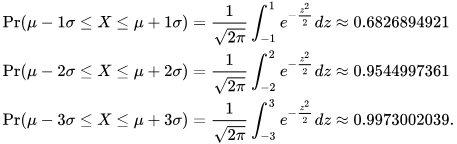
> Kết luận: Theo quy tắc ngón tay cái "2\sigma"trong thống kê (với độ tin cậy 95%), cho thấy rằng các biến thực sự ảnh hưởng đến biến mục tiêu $\text{medv}$ và dấu "-" khẳng định mối quan hệ nghịch biến giữa chúng.

>> Nguồn tham khảo: [Wikipedia](https://translate.google.com/translate?u=https://en.wikipedia.org/wiki/68%25E2%2580%259395%25E2%2580%259399.7_rule&hl=vi&sl=en&tl=vi&client=srp)

#### b. Sử dụng mô hình

Dùng mô hình huấn luyện được để dự đoán cho các điểm dữ liệu mới có (`indus`, `age`, `dis`) lần lượt là `(11, 68, 4)`, `(6, 35, 2)`, `(19, 74, 8)`.

In [19]:
# Write your code here
# 1. Tạo DataFrame cho dữ liệu mới
new_data_raw = spark.createDataFrame(
    [(11, 68, 4), (6, 35, 2), (19, 74, 8)], ["indus", "age", "dis"]
)

# 2. Biến đổi dữ liệu mới bằng assembler đã tạo ở bước trước
# Lưu ý: Phải dùng đúng assembler object đã dùng khi train để đảm bảo tính nhất quán
new_data_features = assembler.transform(new_data_raw)

# 3. Thực hiện dự đoán
predictions = lr_model.transform(new_data_features)

# 4. Hiển thị kết quả
predictions.select("indus", "age", "dis", "prediction").show()

+-----+---+---+------------------+
|indus|age|dis|        prediction|
+-----+---+---+------------------+
|   11| 68|  4|22.370810825866748|
|    6| 35|  2| 32.24076584405401|
|   19| 74|  8|  9.74286069912749|
+-----+---+---+------------------+



### **Câu hỏi 2**: Train/test split

Tiếp tục với input là các biến `indus`, `age`, `dis`, và output là biến `medv`.

Giữa $80\%$ dữ liệu để làm training set, $20\%$ còn lại để làm test set, thế giá trị của `seed` là MSSV của bạn.

In [26]:
trainDF, testDF = bostonFeaturizedDF.randomSplit([.8, .2], seed = 22110238)
print(f"Số phần tử trong training set: {trainDF.cache().count()}")
print(f"Số phần tử trong test set: {testDF.cache().count()}")

Số phần tử trong training set: 388
Số phần tử trong test set: 118


#### a. Thực hiện lại các bước tương tự như hương dẫn ở trên 

i. Huấn luyện mô hình trên training set

In [27]:
# Write your code here
from pyspark.ml.regression import LinearRegression

# Khởi tạo mô hình Linear Regression
# featuresCol là cột vector đầu vào, labelCol là cột giá trị cần dự đoán
lr = LinearRegression(featuresCol="features", labelCol="medv")

# Huấn luyện mô hình trên tập dữ liệu đã chuẩn bị
lr_model = lr.fit(trainDF)

ii. In kết quả của mô hình (các hệ số (`Coefficients`, `Intercept`), `RMSE score`, và $R^2$ `score`) trên training set

In [28]:
# Write your code here
# Lấy đối tượng summary từ mô hình đã huấn luyện
training_summary = lr_model.summary

# In ra các hệ số (Coefficients) và hệ số chặn (Intercept)
print("Coefficients (Hệ số): {}".format(lr_model.coefficients))
print("Intercept (Hệ số chặn): {}".format(lr_model.intercept))

# In ra R2 score
print("R2 Score: {}".format(training_summary.r2))

Coefficients (Hệ số): [5.487664678375543,-0.12219440902010871,-0.5515690552908515]
Intercept (Hệ số chặn): -4.624952349817319
R2 Score: 0.6566013322820179


b. Đánh giá mô hình trên test set (in ra `RMSE score`)

In [29]:
# Write your code here
# In ra RMSE
print("RMSE: {}".format(training_summary.rootMeanSquaredError))

# In ra các chỉ số thống kê chi tiết cho từng hệ số
print(
    "Standard Errors (Sai số chuẩn): {}".format(
        training_summary.coefficientStandardErrors
    )
)
print("T-Values: {}".format(training_summary.tValues))
print("P-Values: {}".format(training_summary.pValues))

RMSE: 5.189825958371452
Standard Errors (Sai số chuẩn): [0.47900526417620554, 0.045841195305180084, 0.0522628867733738, 3.42370781629035]
T-Values: [11.45637655530413, -2.665602591874402, -10.553742614383438, -1.3508607036533098]
P-Values: [0.0, 0.008009490126466012, 0.0, 0.177535499245717]


### **Câu hỏi 3**: Regularization với Ridge, Lasso, và ElasticNet regression

Tiếp tục với input là các biến `indus`, `age`, `dis`, và output là biến `medv`.

Điều chỉnh các tham số `regParam` (or `lambda`, regularization parameter) và `elasticNetParam` (or `alpha`, the ElasticNet mixing parameter, in range [0, 1]. For `alpha = 0`, the penalty is an `L2 penalty`. For `alpha = 1`, it is an `L1 penalty`.) của `LinearRegression`. Xem thêm ở [đây](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.LinearRegression.html#pyspark.ml.regression.LinearRegression).

- `regParam = 0`: ordinary least squares (OLS)

- `regParam != 0, elasticNetParam = 0`: L2 (Ridge regression)

- `regParam != 0, elasticNetParam = 1`: L1 (Lasso regression)

- `regParam != 0, elasticNetParam != 0`: L2 + L1 (ElasticNet regression)

#### a. `regParam = 0`: ordinary least squares

Thiết lập `regParam = 0` để tạo mô hình Linear Regression.

In [30]:
# Write your code here
from pyspark.ml.regression import LinearRegression

# Khởi tạo mô hình với regParam = 0
lr_ols = LinearRegression(featuresCol="features", labelCol="medv", regParam=0.0)

# Huấn luyện mô hình
model_ols = lr_ols.fit(final_data)

# In kết quả
print("--- OLS (Ordinary Least Squares) ---")
print("Coefficients: {}".format(model_ols.coefficients))
print("Intercept: {}".format(model_ols.intercept))
print("RMSE: {}".format(model_ols.summary.rootMeanSquaredError))

--- OLS (Ordinary Least Squares) ---
Coefficients: [-0.7355105640733189,-0.09401564635814376,-1.544942934000961]
Intercept: 43.03426271903088
RMSE: 7.766715476913002


#### b. `regParam != 0, elasticNetParam = 0`: L2 (Ridge Regression)

Chọn một giá trị khác 0 cho tham số `regParam` để tạo mô hình Ridge Regression.

In [37]:
# Write your code here
# Khởi tạo mô hình Ridge (L2) với regParam = 0.22110238, elasticNetParam = 0.0
lr_ridge = LinearRegression(
    featuresCol="features", labelCol="medv", regParam=0.2, elasticNetParam=0.0
)

# Huấn luyện mô hình
model_ridge = lr_ridge.fit(final_data)

# In kết quả
print("--- Ridge Regression (L2) ---")
print("Coefficients: {}".format(model_ridge.coefficients))
print("RMSE: {}".format(model_ridge.summary.rootMeanSquaredError))

--- Ridge Regression (L2) ---
Coefficients: [-0.6974970709091147,-0.08829103446152495,-1.370197894508917]
RMSE: 7.7705046904963435


#### c. `regParam != 0, elasticNetParam = 1`: L1 (Lasso regression)

Chọn một giá trị khác 0 cho tham số `regParam` và thiết lập `elasticNetParam = 1` để tạo mô hình Lasso Regression.

In [38]:
# Write your code here
# Khởi tạo mô hình Lasso (L1) với regParam = 0.22110238, elasticNetParam = 1.0
lr_lasso = LinearRegression(
    featuresCol="features", labelCol="medv", regParam=0.22110238, elasticNetParam=1.0
)

# Huấn luyện mô hình
model_lasso = lr_lasso.fit(final_data)

# In kết quả
print("--- Lasso Regression (L1) ---")
print("Coefficients: {}".format(model_lasso.coefficients))
print("RMSE: {}".format(model_lasso.summary.rootMeanSquaredError))

--- Lasso Regression (L1) ---
Coefficients: [-0.6493853427238179,-0.06831986637396191,-0.984273867308295]
RMSE: 7.802110155360086


#### d. `regParam != 0, elasticNetParam != 0`: L2 + L1 (ElasticNet Regression)

Chọn hai giá trị khác 0 cho tham số `regParam` và `elasticNetParam` để tạo mô hình ElasticNet Regression.

In [39]:
# Write your code here
# Khởi tạo mô hình ElasticNet với regParam = 0.22110238 và elasticNetParam = 0.5
lr_elastic = LinearRegression(
    featuresCol="features", labelCol="medv", regParam=0.22110238, elasticNetParam=0.5
)

# Huấn luyện mô hình
model_elastic = lr_elastic.fit(final_data)

# In kết quả
print("--- ElasticNet Regression ---")
print("Coefficients: {}".format(model_elastic.coefficients))
print("RMSE: {}".format(model_elastic.summary.rootMeanSquaredError))

--- ElasticNet Regression ---
Coefficients: [-0.672582363157572,-0.07849175137447399,-1.1778585009672404]
RMSE: 7.782140679579816


#### e. Nhận xét kết quả của các mô hình ở a, b, c, d.

- Về độ chính xác trên tập huấn luyện (RMSE): Mô hình OLS (a) có RMSE thấp nhất (7.767), cho thấy nó khớp tốt nhất với dữ liệu huấn luyện hiện tại. Các mô hình có điều chuẩn (Regularization) như Ridge, Lasso, và ElasticNet đều có RMSE cao hơn một chút do việc thêm thành phần phạt (penalty) vào hàm mất mát, chấp nhận hy sinh một chút độ chính xác trên tập train để đổi lấy khả năng tổng quát hóa.

- Về các hệ số hồi quy (Coefficients): Các mô hình Regularization (b, c, d) đều làm giảm độ lớn tuyệt đối của các hệ số (hiện tượng co - shrinkage) so với OLS. Trong đó, Lasso (c) có tác động mạnh nhất, làm giảm đáng kể trọng số của các biến (ví dụ: hệ số thứ 3 giảm từ -1.54 ở OLS xuống còn -0.98 ở Lasso).

Kết luận: Sự chênh lệch RMSE giữa các mô hình là không lớn. Mặc dù OLS tốt nhất trên tập train, nhưng các mô hình Regularization (đặc biệt là Ridge hoặc ElasticNet) thường sẽ ổn định hơn và tránh được hiện tượng quá khớp (overfitting) khi áp dụng vào dữ liệu thực tế hoặc tập kiểm thử (test set) mới.



### **Câu hỏi 4**: Tạo ML pipeline và đánh giá các mô hình dùng cross validation

![cross-validation-model-selection](./image/cross_val.png)

**Tham khảo**
1. ML Pipeline: https://spark.apache.org/docs/latest/ml-pipeline.html
2. ML Tuning: https://spark.apache.org/docs/latest/ml-tuning.html



**Lưu ý:** 

- Ở câu hỏi này, bạn cần sử dụng tất cả các thuộc tính khác `medv` làm input (`features`) và `medv` làm output (`label`) để tận dụng tối đa thông tin đã có nhất có thể. Bạn nên tiền xử lý các thuộc tính phân loại (categorical features) trước khi đưa vào huấn luyện các mô hình. Tham khảo: `pyspark.ml.feature.OneHotEncoder` và `pyspark.ml.feature.StringIndexer`.

- Bạn cần thiết lập các tham số `regParam` và `elasticNetParam` là một danh sách các giá trị để bao gồm các mô hình Linear Regression, Ridge Regression, Lasso Regression, và ElasticNet Regression. Mỗi tham số tối thiểu 5 giá trị khác nhau. Chú ý rằng: 

    - `regParam != 0` và `elasticNetParam = 0` ứng với Ridge Regression
    
    - `regParam != 0` và `elasticNetParam = 1` ứng với Lasso Regression
    
    - `regParam != 0` và `elasticNetParam != 0` ứng với ElasticNet Regression

In [ ]:
# Write your code here
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator

# 1. Xác định các cột Input và Output
# 'bostonDF' là DataFrame chứa dữ liệu Boston Housing
# 'medv' là biến mục tiêu (label)
# 'chas' thường là biến phân loại (categorical) trong bộ dữ liệu này
cat_cols = ["chas"]
# Các cột còn lại là biến số (numerical)
num_cols = [c for c in bostonDF.columns if c not in cat_cols and c != "medv"]

stages = []

# 2. Tiền xử lý dữ liệu (Preprocessing)
# Duyệt qua các cột phân loại để Index và Encode
for cat_col in cat_cols:
    # StringIndexer: Chuyển đổi giá trị category thành chỉ số (index)
    # setHandleInvalid("keep") giúp xử lý các giá trị mới chưa thấy trong tập train
    indexer = StringIndexer(
        inputCol=cat_col, outputCol=cat_col + "_idx", handleInvalid="keep"
    )

    # OneHotEncoder: Chuyển đổi chỉ số thành vector nhị phân (dummy variables)
    encoder = OneHotEncoder(
        inputCols=[indexer.getOutputCol()], outputCols=[cat_col + "_vec"]
    )

    stages += [indexer, encoder]

# VectorAssembler: Gom tất cả các cột input (số + vector phân loại) thành một cột 'features' duy nhất
assembler_inputs = num_cols + [c + "_vec" for c in cat_cols]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")
stages.append(assembler)

# 3. Khởi tạo mô hình (Estimator)
# LinearRegression sẽ là bước cuối cùng của Pipeline
lr = LinearRegression(labelCol="medv", featuresCol="features")
stages.append(lr)

# Tạo Pipeline hoàn chỉnh
pipeline = Pipeline(stages=stages)

# 4. Thiết lập lưới tham số (ParamGrid)
# regParam: Tham số chuẩn hóa (lambda). 0 là OLS, >0 là có chuẩn hóa.
# elasticNetParam: Tỷ trọng giữa L1 và L2. 0 là Ridge, 1 là Lasso, (0,1) là ElasticNet.
paramGrid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.0, 0.01, 0.1, 0.5, 1.0])
    .addGrid(lr.elasticNetParam, [0.0, 0.25, 0.5, 0.75, 1.0])
    .build()
)

# 5. Thiết lập CrossValidator
# Sử dụng 3-fold cross validation (chia dữ liệu làm 3 phần)
crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=RegressionEvaluator(
        labelCol="medv", predictionCol="prediction", metricName="rmse"
    ),
    numFolds=3,
)

# 6. Huấn luyện và Tìm mô hình tốt nhất
print("Đang huấn luyện Cross-Validation...")
cv_model = crossval.fit(bostonDF)

# 7. Kết quả đánh giá tất cả tham số cấu hình (Linear, Ridge, Lasso, ElasticNet)
results = []
for param_map, rmse in zip(paramGrid, cv_model.avgMetrics):
    results.append(
        (
            param_map[lr.regParam],
            param_map[lr.elasticNetParam],
            rmse,
        )
    )

# Sắp xếp theo RMSE tăng dần để dễ so sánh
results = sorted(results, key=lambda x: x[2])

print("\n--- TỔNG HỢP KẾT QUẢ CROSS-VALIDATION ---")
print(f"{'regParam':>8} | {'elasticNet':>10} | {'RMSE':>8}")
print("-" * 34)
for rp, en, rmse in results:
    print(f"{rp:8.3f} | {en:10.3f} | {rmse:8.4f}")

# Mô hình tốt nhất
best_model = cv_model.bestModel
best_lr_stage = best_model.stages[-1]

print("\n--- MÔ HÌNH TỐT NHẤT ---")
print(f"Best regParam          : {best_lr_stage.getRegParam()}")
print(f"Best elasticNetParam   : {best_lr_stage.getElasticNetParam()}")
print(f"Best RMSE (validation) : {min(cv_model.avgMetrics):.4f}")
print(f"Coefficients           : {best_lr_stage.coefficients}")
print(f"Intercept              : {best_lr_stage.intercept}")

Đang huấn luyện Cross-Validation...

--- TỔNG HỢP KẾT QUẢ CROSS-VALIDATION ---
regParam | elasticNet |     RMSE
----------------------------------
   0.010 |      1.000 |   4.8786
   0.010 |      0.750 |   4.8787
   0.010 |      0.500 |   4.8788
   0.010 |      0.250 |   4.8789
   0.010 |      0.000 |   4.8791
   0.100 |      0.000 |   4.8792
   0.000 |      0.000 |   4.8794
   0.000 |      0.250 |   4.8794
   0.000 |      0.500 |   4.8794
   0.000 |      0.750 |   4.8794
   0.000 |      1.000 |   4.8794
   0.100 |      0.250 |   4.8823
   0.100 |      0.500 |   4.8913
   0.500 |      0.000 |   4.9019
   0.100 |      0.750 |   4.9068
   0.100 |      1.000 |   4.9279
   1.000 |      0.000 |   4.9421
   0.500 |      0.250 |   4.9870
   0.500 |      0.500 |   5.0880
   1.000 |      0.250 |   5.1186
   0.500 |      0.750 |   5.1960
   0.500 |      1.000 |   5.2818
   1.000 |      0.500 |   5.3035
   1.000 |      0.750 |   5.3716
   1.000 |      1.000 |   5.4531

--- MÔ HÌNH TỐT NHẤT ---
Be

#### Nhận xét, so sánh kết quả của các mô hình Linear Regression, Ridge Regression, Lasso Regression, và ElasticNet Regression

- Mô hình Lasso Regression (regParam=0.01, elasticNetParam=1.0) đạt hiệu quả tối ưu nhất với RMSE thấp nhất (~4.8786). Tuy nhiên, sự cải thiện này là rất nhỏ so với mô hình Linear Regression thuần túy (OLS với regParam=0 có RMSE ~4.8794). Điều này cho thấy mô hình ít bị quá khớp (overfitting) trên tập dữ liệu này, nên việc áp dụng Regularization chỉ mang lại lợi ích biên (marginal benefit).

- Tác động mạnh của tham số regParam (Mức độ phạt): Các mô hình tốt nhất đều tập trung ở mức regParam rất nhỏ (0.01). Khi tăng regParam lên cao (0.5 hoặc 1.0), hiệu suất của tất cả các mô hình đều giảm sút đáng kể (RMSE tăng vọt lên trên 5.0, thậm chí 5.45 với Lasso). Điều này chứng tỏ việc phạt quá nặng các hệ số sẽ dẫn đến hiện tượng "underfitting" (mô hình quá đơn giản, không bắt được quy luật dữ liệu).

- Khả năng chọn lọc đặc trưng (Feature Selection) của Lasso: Quan sát hệ số (Coefficients) của mô hình tốt nhất, ta thấy có một hệ số tại vị trí index 5 bị đưa về đúng bằng 0.0. Đây là đặc điểm khác biệt của Lasso so với Ridge (Ridge chỉ làm hệ số nhỏ đi chứ không bằng 0). Lasso đã xác định biến này không đóng góp giá trị cho việc dự đoán và loại bỏ nó hoàn toàn, giúp mô hình gọn nhẹ hơn.
